# Work in progress

In [1]:
from utils_agroforestry import *
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# Load agroforestry composition tables
agroforest = {
    0: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/aguacate_vegetation.csv"),
    1: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/piso_verde_vegetation.csv"),
}

# Add system_id for linking to agroforestry composition
points_data = [
    {"lon": -71.252111, "lat": 19.293583, "plot_area_m2": 4184, "system_id": 0},
    {"lon": -71.293917, "lat": 19.308333, "plot_area_m2": 8000, "system_id": 1},
]

# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    points_data,
    geometry=[Point(p["lon"], p["lat"]) for p in points_data],
    crs="EPSG:4326"
)

# Extract features and simulate composition
df_results = extract_features_with_composition(
    gdf=gdf_points,
    agroforest_dict=agroforest,
    raster_source="dominican_republic"
)

print(df_results)


✅ Extracted from: ESA_WorldCover_10m_2021_v200_N18W072_Map.tif, mean: 10.00
✅ Extracted from: ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif, mean: 19.86
✅ Extracted from: 20N_080W.tif, mean: 93.00
✅ Extracted from: ESA_WorldCover_10m_2021_v200_N18W072_Map.tif, mean: 10.00
✅ Extracted from: ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif, mean: 23.55
✅ Extracted from: 20N_080W.tif, mean: 81.33
  land_use_class  canopy_height  forest_cover        lon        lat  \
0     Tree cover      19.857143     93.000000 -71.252111  19.293583   
1     Tree cover      23.550000     81.333333 -71.293917  19.308333   

   plot_area_m2  system_id                               agroforestry_species  
0          4184          0  [{'species': 'Inga Fagifolia  ', 'type': '1st ...  
1          8000          1  [{'species': 'Soymida febrifuga', 'type': '1st...  


In [2]:
df_results["geometry"] = df_results.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)


In [3]:
# Run simulations for each row
simulated_results = []
for idx, row in df_results.iterrows():
    species_df = agroforest[idx]  # match by row index
    result_df = simulate_agroforestry_plot(row, row.plot_area_m2, species_df)
    if result_df is not None:
        result_df["plot_index"] = idx
        simulated_results.append(result_df)

# Combine results
agroforest_df = pd.concat(simulated_results, ignore_index=True)


In [4]:
import pandas as pd
from config import ECOCROP_PATH

# Load EcoCrop database
ecocrop = pd.read_csv(ECOCROP_PATH, encoding="latin1")

# Clean EcoCrop species names
ecocrop["species_clean"] = ecocrop["ScientificName"].str.strip().str.lower()

# Select relevant climate and drought-related columns
climate_cols = [
    "species_clean",
    "TMIN", "TOPMN", "TOPMX", "TMAX",
    "RMIN", "ROPMN", "ROPMX", "RMAX",
    "PHOTO", "KTMPR", "KTMP", "CLIZ",
    "DRA", "DRAR"
]
ecocrop_subset = ecocrop[climate_cols]

# Clean and match with agroforest_df
agroforest_df["species_clean"] = agroforest_df["species"].str.strip().str.lower()
agroforest_df = agroforest_df.merge(ecocrop_subset, on="species_clean", how="left")


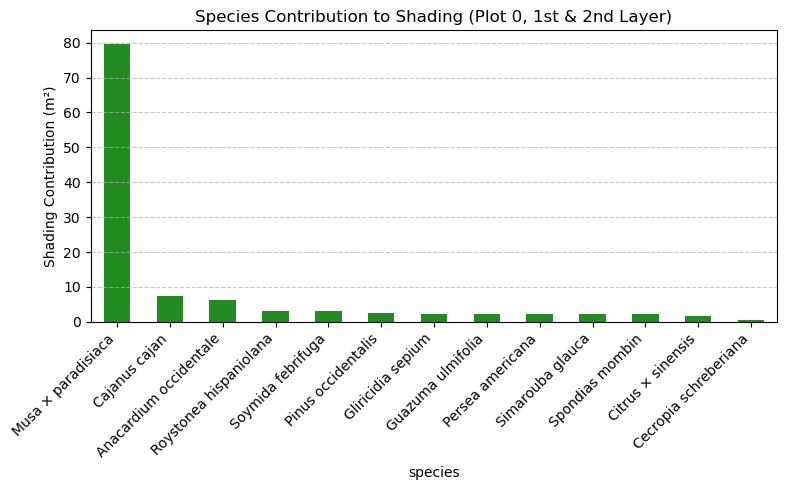

In [5]:
import matplotlib.pyplot as plt

# Filter to first and second layer trees in plot 0
subset = agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
]

# Group by species and sum shading_m2
shading_contrib = (
    subset.groupby("species")["shading_m2"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
shading_contrib.plot(kind="bar", color="forestgreen")
plt.ylabel("Shading Contribution (m²)")
plt.title("Species Contribution to Shading (Plot 0, 1st & 2nd Layer)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [6]:
import os
from climada.hazard.base import Hazard
from config import DATA_DIR, TERRACLIMATE_PATHS
from utils_hazards import (
    get_aggregates, compute_spei_3,
    generate_gev_sample_field, create_hazard_from_array
)

# === Settings ===
LAT_BOUNDS_DR = (20.0, 17.5)
LON_BOUNDS_DR = (-72.0, -68.0)
haz_types = ["TM", "PR", "SPEI"]
output_dir = os.path.join(DATA_DIR, "hazards_dominican_republic")
os.makedirs(output_dir, exist_ok=True)

def get_hazard_path(scenario, haz_type):
    return os.path.join(output_dir, f"write_hazard_{scenario}_{haz_type}.hdf5")

def load_hazard_from_file(scenario, haz_type):
    path = get_hazard_path(scenario, haz_type)
    haz = Hazard.from_hdf5(path)
    print(f"📂 Loaded: {path}")
    return haz

def save_hazard_to_file(hazard, scenario, haz_type):
    path = get_hazard_path(scenario, haz_type)
    hazard.write_hdf5(path)
    print(f"💾 Saved: {path}")

# === Main loop ===
hazard_dict = {}

for scenario, path in TERRACLIMATE_PATHS.items():
    print(f"\n🚀 Processing scenario: {scenario}")
    all_exist = all(os.path.exists(get_hazard_path(scenario, haz_type)) for haz_type in haz_types)

    if all_exist:
        print("✅ All hazard files found — skipping computation.")
        hazard_dict[scenario] = {
            haz_type: load_hazard_from_file(scenario, haz_type)
            for haz_type in haz_types
        }
        continue

    print("🧮 Computing hazards...")
    tmean, ppt, ppt_monthly, pet_monthly = get_aggregates(path)

    print("🌵 Computing SPEI...")
    spei_3 = compute_spei_3(ppt_monthly, pet_monthly)
    spei_yearly = spei_3.groupby(spei_3.time.dt.year).min("time")

    print("🎲 Sampling synthetic HOT, DRY, and DRIEST years (GEV)...")
    tmean_100yrs = generate_gev_sample_field(tmean, n_years=100)
    ppt_100yrs = generate_gev_sample_field(ppt, n_years=100, invert=True)
    spei_100yrs = generate_gev_sample_field(spei_yearly, n_years=100, invert=True)

    print("🌍 Creating CLIMADA Hazard objects...")
    haz_tmean = create_hazard_from_array(tmean_100yrs, haz_type="TM", units="degC")
    haz_ppt = create_hazard_from_array(ppt_100yrs, haz_type="PR", units="mm")
    haz_spei = create_hazard_from_array(spei_100yrs, haz_type="SPEI", units="index")

    # Save to disk
    save_hazard_to_file(haz_tmean, scenario, "TM")
    save_hazard_to_file(haz_ppt, scenario, "PR")
    save_hazard_to_file(haz_spei, scenario, "SPEI")

    hazard_dict[scenario] = {
        "TM": haz_tmean,
        "PR": haz_ppt,
        "SPEI": haz_spei
    }

print("\n✅ Done: HOT, DRY & DRIEST hazard generation or loading completed.")



🚀 Processing scenario: plus2C
✅ All hazard files found — skipping computation.
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_plus2C_TM.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_plus2C_PR.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_plus2C_SPEI.hdf5

🚀 Processing scenario: historical
✅ All hazard files found — skipping computation.
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_historical_TM.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_historical_PR.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_historical_SPEI.hdf5

✅ Done: HOT, DRY & DRIEST hazard generation or loading completed.


In [7]:
tmean, ppt, ppt_monthly, pet_monthly = get_aggregates(path)


📂 Loading 38 files for tmin
📂 Loading 38 files for tmax
📂 Loading 38 files for ppt
📂 Loading 38 files for pet


In [87]:
def define_temp_prec_impfs(df, tmean, ppt, T_BUFFER=5, P_BUFFER=800, temp_shift=0.0, precip_factor=1.0):
    impf_set = ImpactFuncSet()
    species_to_temp_id, species_to_prec_id = {}, {}
    fallback_ids = {}
    counter = 1

    for _, row in df.iterrows():
        species = row["species"]
        lat, lon = row.geometry.y, row.geometry.x

        tmin = row.get("TMIN")
        tmax = row.get("TMAX")
        t_opt_min = row.get("TOPMN", tmin)
        t_opt_max = row.get("TOPMX", tmax)

        rmin = row.get("RMIN")
        rmax = row.get("RMAX")
        r_opt_min = row.get("ROPMN", rmin)
        r_opt_max = row.get("ROPMX", rmax)

        if species in species_to_temp_id and species in species_to_prec_id:
            continue

        if any(pd.isnull([tmin, tmax, rmin, rmax])):
            loc_key = (lat, lon)
            if loc_key in fallback_ids:
                temp_id, prec_id = fallback_ids[loc_key]
            else:
                t_loc, p_loc = get_climate_at_point(tmean, ppt, lat, lon)

                impf_temp = make_trapezoidal_impact_func(
                    "TM", f"fallback_{lat:.2f}_{lon:.2f}",
                    t_loc - T_BUFFER + temp_shift,
                    t_loc - 1 + temp_shift,
                    t_loc + 1 + temp_shift,
                    t_loc + T_BUFFER + temp_shift,
                    counter
                )
                impf_set.append(impf_temp)
                temp_id = counter
                counter += 1

                p_loc_scaled = p_loc * precip_factor
                impf_prec = make_trapezoidal_impact_func(
                    "PR", f"fallback_{lat:.2f}_{lon:.2f}",
                    max(p_loc_scaled - P_BUFFER, 0),
                    p_loc_scaled - 200,
                    p_loc_scaled + 200,
                    p_loc_scaled + P_BUFFER,
                    counter
                )
                impf_set.append(impf_prec)
                prec_id = counter
                counter += 1

                fallback_ids[loc_key] = (temp_id, prec_id)

            species_to_temp_id[species] = temp_id
            species_to_prec_id[species] = prec_id

        else:
            impf_temp = make_trapezoidal_impact_func(
                "TM", species,
                tmin + temp_shift,
                t_opt_min + temp_shift,
                t_opt_max + temp_shift,
                tmax + temp_shift,
                counter
            )
            impf_set.append(impf_temp)
            species_to_temp_id[species] = counter
            counter += 1

            impf_prec = make_trapezoidal_impact_func(
                "PR", species,
                rmin * precip_factor,
                r_opt_min * precip_factor,
                r_opt_max * precip_factor,
                rmax * precip_factor,
                counter
            )
            impf_set.append(impf_prec)
            species_to_prec_id[species] = counter
            counter += 1

    return impf_set, species_to_temp_id, species_to_prec_id


2025-06-20 17:16:08,587 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.
2025-06-20 17:16:08,594 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.
2025-06-20 17:16:08,598 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.
2025-06-20 17:16:08,598 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


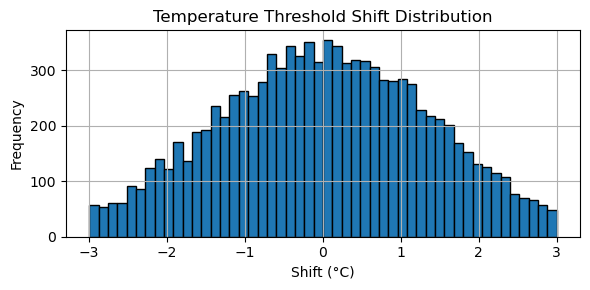

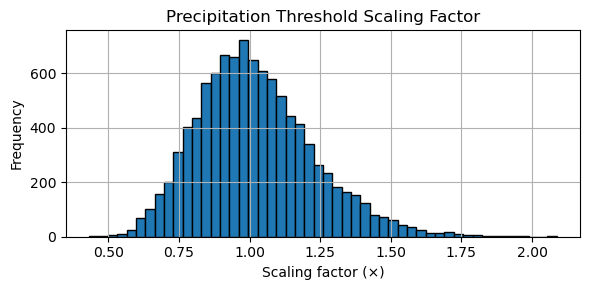

In [92]:
import scipy.stats as stats
import copy
import matplotlib.pyplot as plt
from climada.engine.unsequa import InputVar
from climada.entity.impact_funcs import ImpactFuncSet

# Full function that returns both the impact function set and the updated dataframe
def impf_func_full(x_temp_shift, x_precip_factor, base_df=agroforest_df.copy(), tmean=tmean, ppt=ppt):
    # Step 1: Define impact functions with shifted thresholds
    impf_temp_prec, species_to_temp_id, species_to_prec_id = define_temp_prec_impfs(
        base_df, tmean, ppt, temp_shift=x_temp_shift, precip_factor=x_precip_factor
    )

    # Step 2: Wind (TC)
    impf_tc = define_tc_impfs()

    # Step 3: Drought
    species_df = base_df
    spei_dict = generate_spei_dict_from_dra(species_df)
    impf_drought, species_to_drought_id = define_drought_impfs(spei_dict)

    # Step 4: Assign IDs
    df = assign_impact_function_ids(
        base_df.copy(),
        species_to_temp_id,
        species_to_prec_id,
        species_to_drought_id
    )

    # Step 5: Merge all impact functions
    impf_set = ImpactFuncSet()
    for sub_set in [impf_temp_prec, impf_tc, impf_drought]:
        for haz_funcs in sub_set.get_func().values():
            for impf in haz_funcs.values():
                impf_set.append(copy.deepcopy(impf))

    return impf_set, df

# Short wrapper for InputVar (returns only the impact function set)
def impf_func(x_temp_shift, x_precip_factor):
    impf_set, _ = impf_func_full(x_temp_shift, x_precip_factor)
    return impf_set

# Define distributions: temperature threshold shift (truncated normal), precip scale factor (lognormal)
from scipy.stats import truncnorm, lognorm

# Temperature shift distribution: truncated normal (-3 to +3°C, mean 0, std 1.5)
mu_temp, sigma_temp = 0.0, 1.5
a, b = (-3 - mu_temp) / sigma_temp, (3 - mu_temp) / sigma_temp
temp_distr = truncnorm(a, b, loc=mu_temp, scale=sigma_temp)

# Precipitation factor distribution: lognormal with median ~1.0 and ~20–30% spread
precip_distr = lognorm(s=0.2, scale=1.0)

impf_distr = {
    "x_temp_shift": temp_distr,
    "x_precip_factor": precip_distr
}

# Wrap in InputVar
impf_iv = InputVar(impf_func, impf_distr)

# Test a specific draw (for debugging)
impf_test, agroforest_df = impf_func_full(x_temp_shift=1.2, x_precip_factor=1.1)

# Plot temperature threshold shift distribution
samples_temp = temp_distr.rvs(10000)
plt.figure(figsize=(6, 3))
plt.hist(samples_temp, bins=50, edgecolor='k')
plt.title("Temperature Threshold Shift Distribution")
plt.xlabel("Shift (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot precipitation scaling factor distribution
samples_prec = precip_distr.rvs(10000)
plt.figure(figsize=(6, 3))
plt.hist(samples_prec, bins=50, edgecolor='k')
plt.title("Precipitation Threshold Scaling Factor")
plt.xlabel("Scaling factor (×)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
InputVar(impf_func, impf_distr)

Original total value: 1,063.59
With +20% uncertainty: 1,276.31


<Axes: >

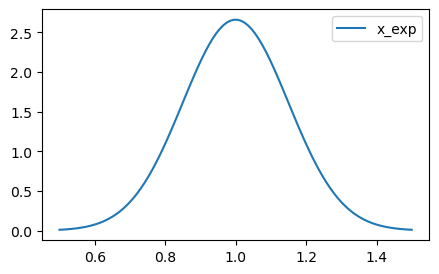

In [93]:
from scipy.stats import truncnorm
from climada.entity import Exposures
from climada.engine.unsequa import InputVar

# Assign the shading as value
agroforest_df['value'] = agroforest_df["shading_m2"]

# Base exposure object with only relevant rows
exp_base = Exposures(data=agroforest_df[
    agroforest_df["type"].isin(["1st tree", "2nd tree"])]
)

# Uncertainty function: scales exposure value
def exp_func(x_exp, exp_base=exp_base):
    exp = exp_base.copy()
    exp.gdf["value"] *= x_exp
    return exp

# Truncated normal: mean = 1.0, std dev = 0.15, bounds = 0.5–1.5
lower, upper = 0.5, 1.5
mu, sigma = 1.0, 0.15
a, b = (lower - mu) / sigma, (upper - mu) / sigma
exp_distr = {"x_exp": truncnorm(a, b, loc=mu, scale=sigma)}

# Wrap in InputVar
exp_iv = InputVar(exp_func, exp_distr)

# Example run: +20% shift
exp_test = exp_iv.func(x_exp=1.2)
print(f"Original total value: {exp_base.gdf['value'].sum():,.2f}")
print(f"With +20% uncertainty: {exp_test.gdf['value'].sum():,.2f}")

# Optional: plot
exp_iv.plot(figsize=(5, 3))


In [ ]:
exp_base.gdf

In [97]:
from climada.engine.unsequa import CalcImpact

calc_imp = CalcImpact(exp_iv, impf_iv, hazard_dict['historical']['PR'])

In [55]:
hazard_dict['historical']

{'TM': <climada.hazard.base.Hazard at 0x310937d10>,
 'PR': <climada.hazard.base.Hazard at 0x311a872d0>,
 'SPEI': <climada.hazard.base.Hazard at 0x30fb0d210>}

In [98]:
output_imp = calc_imp.make_sample(N=2**7, sampling_kwargs={"skip_values": 2**8})
output_imp.get_samples_df().tail()

,x_exp,x_temp_shift,x_precip_factor
1019,0.670781,1.366134,0.901847
1020,0.670781,0.916062,0.901847
1021,1.202747,1.366134,0.901847
1022,1.202747,0.916062,0.804720
1023,1.202747,0.916062,0.901847


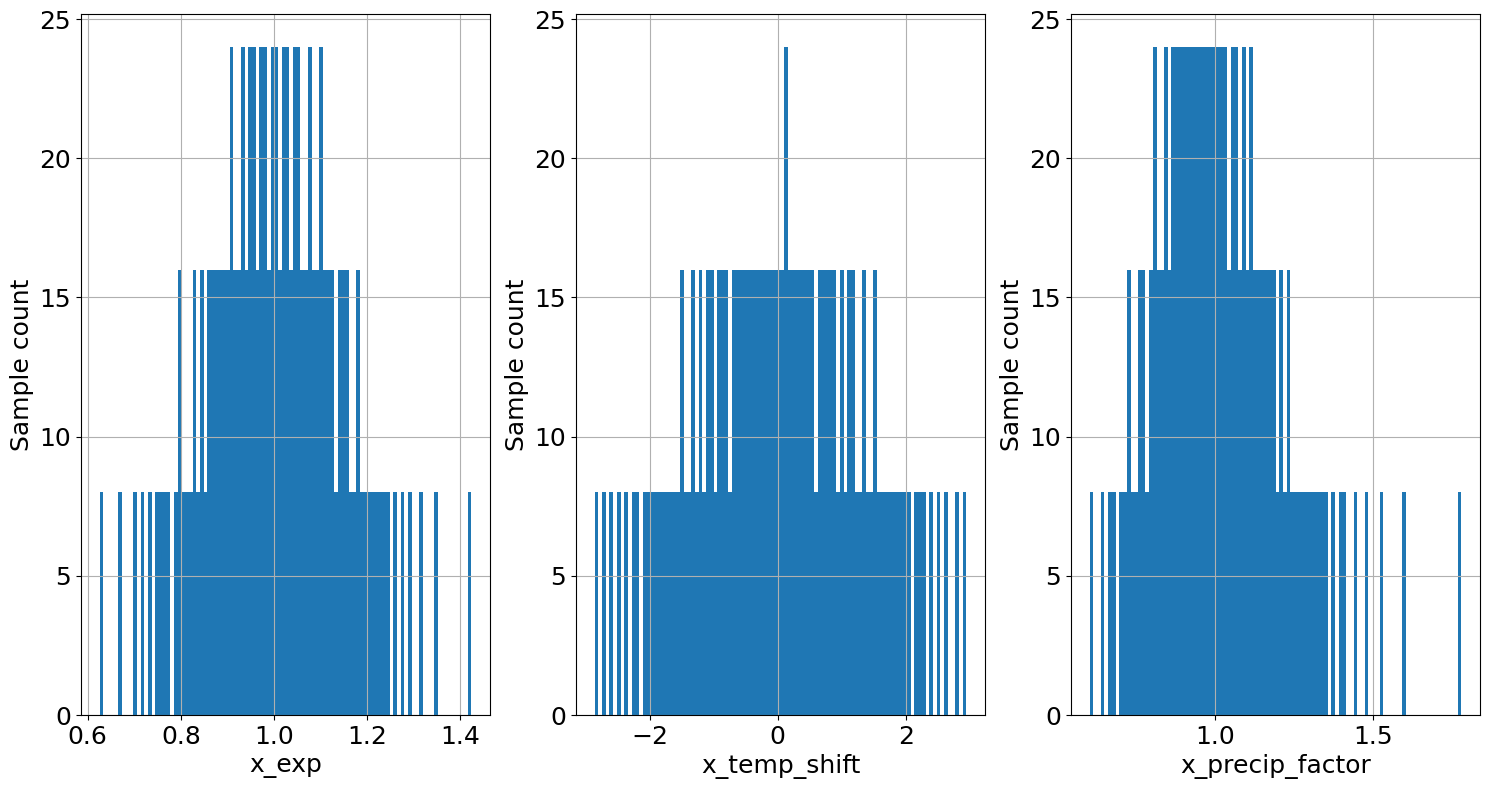

In [99]:
output_imp.plot_sample(figsize=(15, 8));


In [100]:
output_imp = calc_imp.uncertainty(output_imp, rp=[10, 20, 100])


In [101]:
# One uncertainty dataframe
output_imp.get_unc_df("aai_agg").tail()

,aai_agg
1019,72.513722
1020,72.513722
1021,130.021068
1022,64.255588
1023,130.021068


In [102]:
output_imp.get_uncertainty().tail()

,aai_agg,rp10,rp20,rp100
1019,72.513722,265.720670,294.557940,338.106027
1020,72.513722,265.720670,294.557940,338.106027
1021,130.021068,476.451686,528.158489,606.242588
1022,64.255588,377.552325,432.248479,502.025442
1023,130.021068,476.451686,528.158489,606.242588


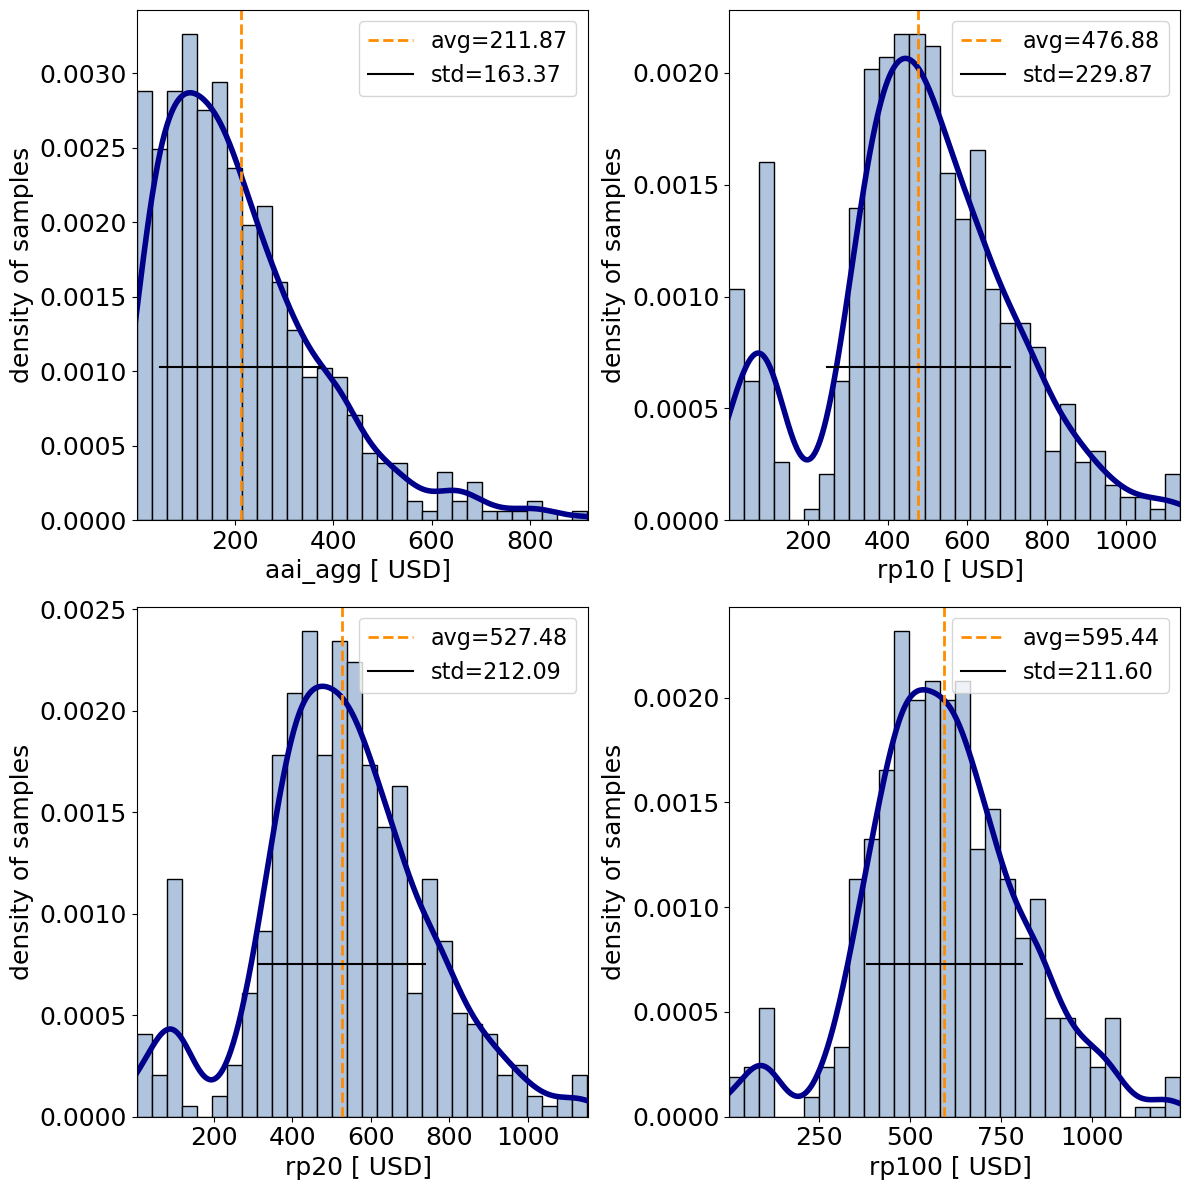

In [103]:
output_imp.plot_uncertainty(figsize=(12, 12));


/Users/szelie/python_projects/climada_python/climada/engine/unsequa/unc_output.py:764: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


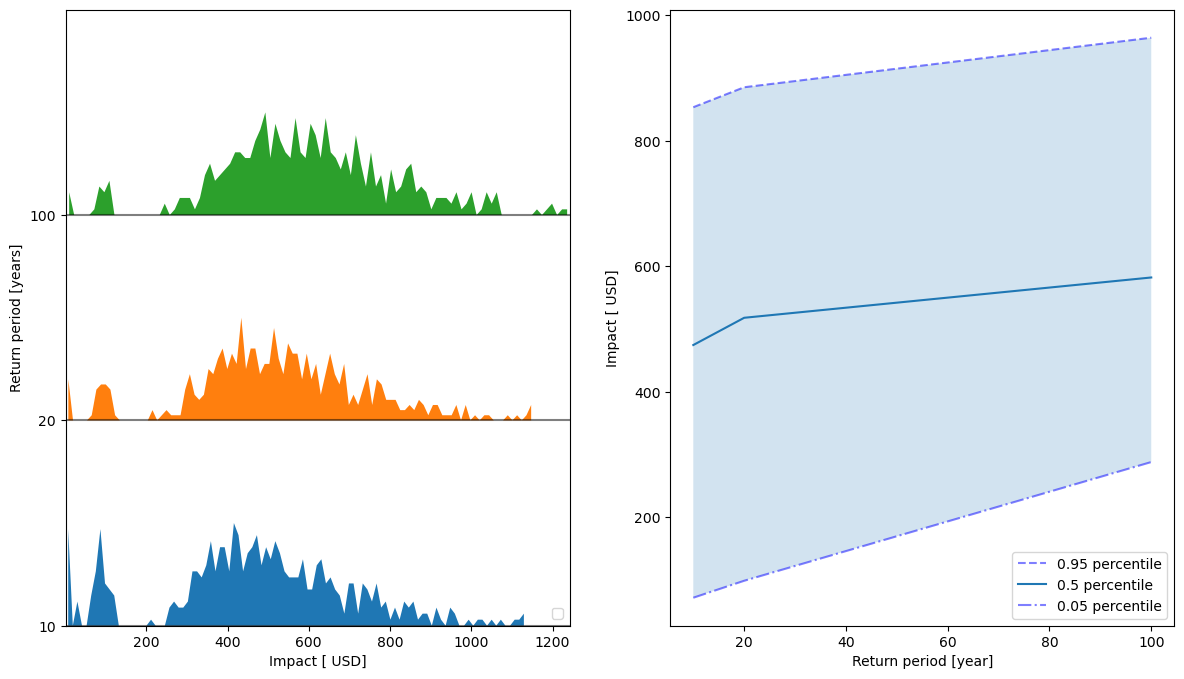

In [104]:
# Specific plot for the return period distributions
output_imp.plot_rp_uncertainty(figsize=(14.3, 8));

In [105]:
output_imp = calc_imp.sensitivity(output_imp)


/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1636: DeprecationWarning: Converting `np.inexact` or

In [106]:
output_imp.sensitivity_metrics

['aai_agg', 'freq_curve']

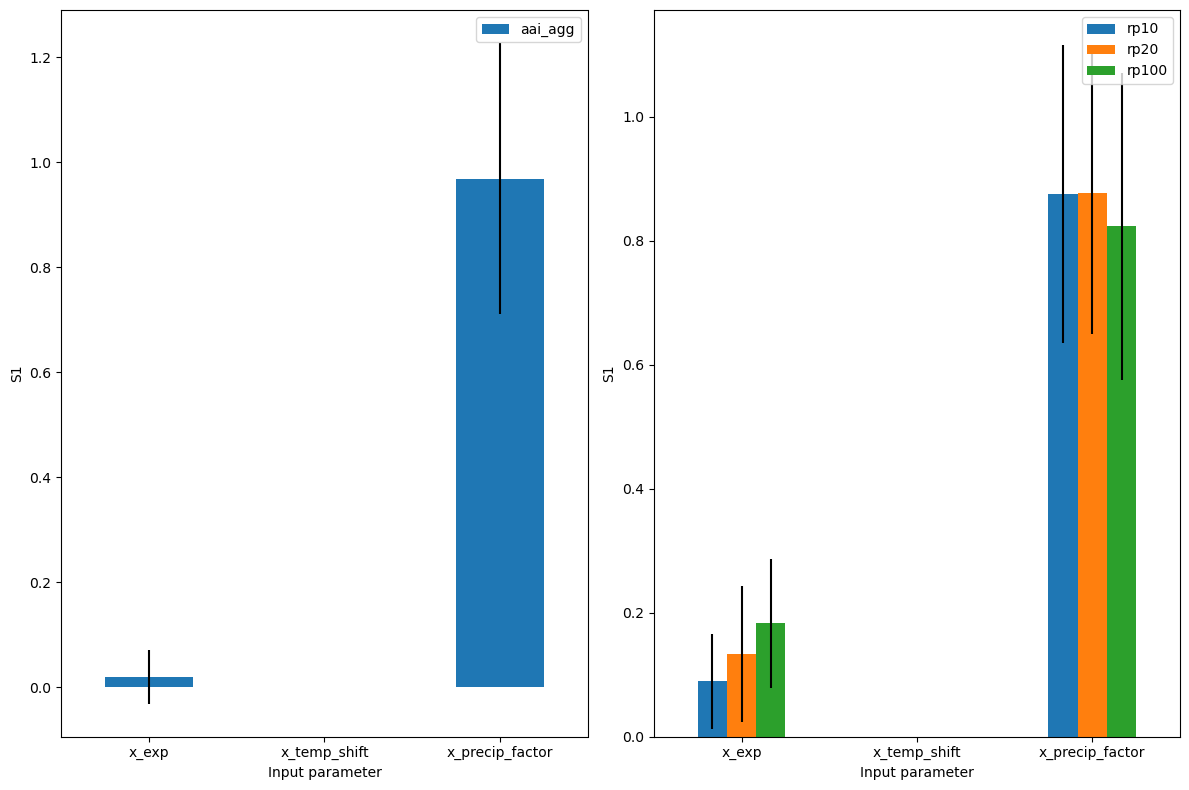

In [107]:
# Default for 'sobol' is to plot 'S1' sensitivity index.
output_imp.plot_sensitivity(figsize=(12, 8));

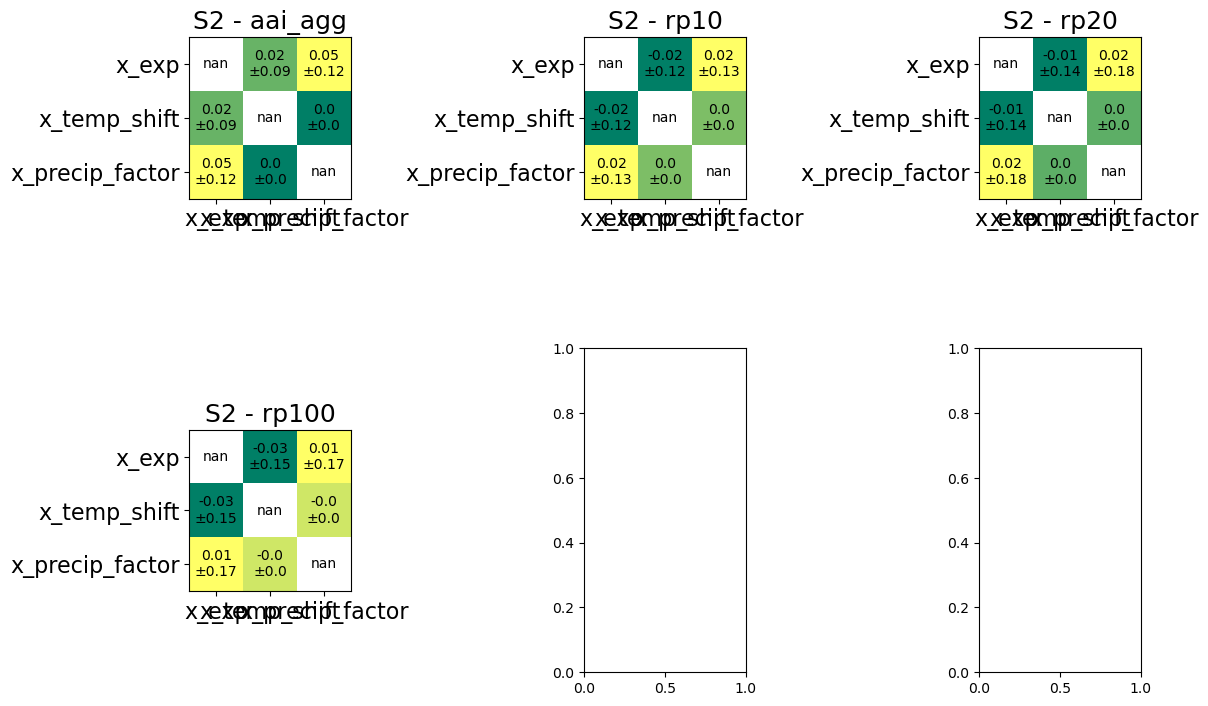

In [108]:
output_imp.plot_sensitivity_second_order(figsize=(12, 8));
